In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import joblib
import random

d:\PYHTON\CODE\PROJECT\xai-ids-project\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
X = pd.read_csv("../data/processed/cicids2017_features_reduced.csv")
y = pd.read_csv("../data/processed/cicids2017_labels.csv").squeeze()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print("Train:", X_train.shape, "Test:", X_test.shape)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

xgb = joblib.load("../models/xgboost.pkl")

Train: (488393, 46) Test: (122099, 46)


In [4]:
# Compute SHAP values

sample_idx = np.random. RandomState(42). choice(X_test.shape[0], 2000, replace=False)
X_shap_sample = X_test_scaled[sample_idx]
X_shap_sample_df = pd.DataFrame(X_shap_sample, columns=X.columns)

explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_shap_sample_df)

print("SHAP values shape:", shap_values.shape)

SHAP values shape: (2000, 46)


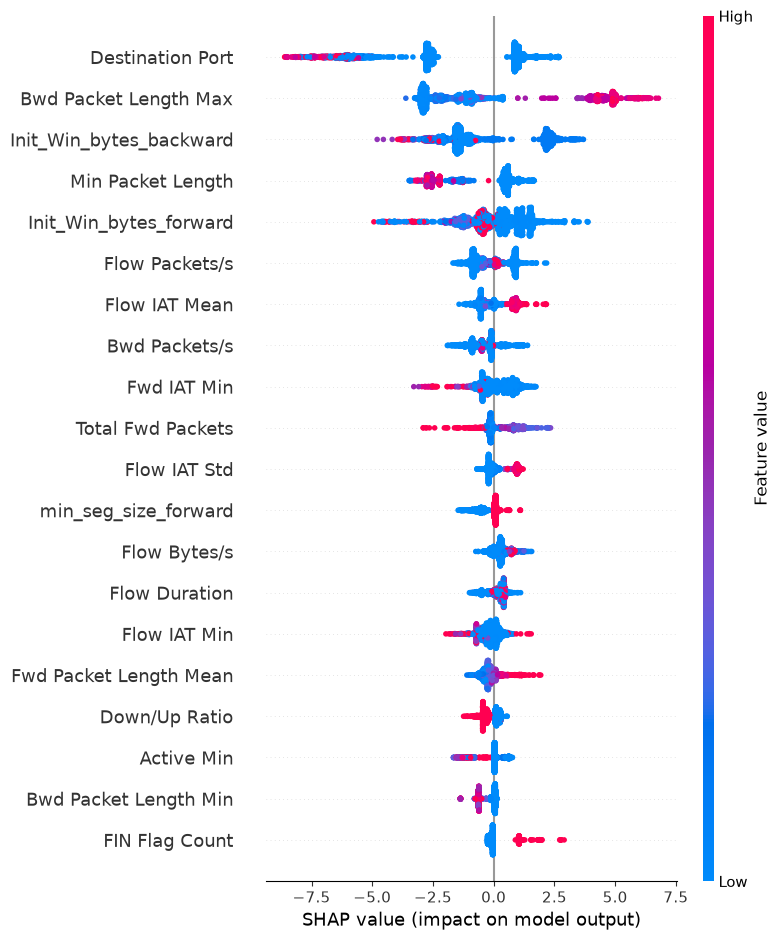

In [ ]:
# Global feature importance
plt.figure()
shap.summary_plot(shap_values, X_shap_sample_df, show=False)
plt.tight_layout()
plt.savefig("../reports/shap_summary_polt.png", dpi=150, bbox_inches='tight')
plt.show()

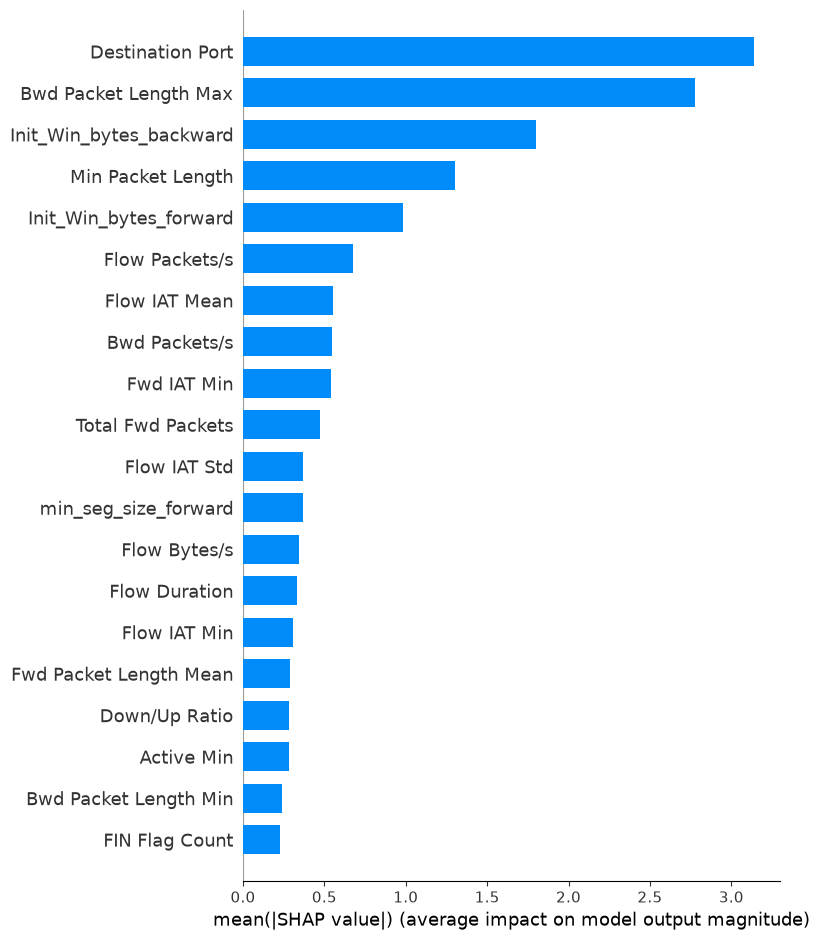

In [7]:
# Bar chart version

plt.figure()
shap.summary_plot(shap_values, X_shap_sample_df, plot_type="bar", show=False)
plt.tight_layout()
plt.savefig("../reports/shap_bar_polt.png", dpi=150, bbox_inches='tight')
plt.show()

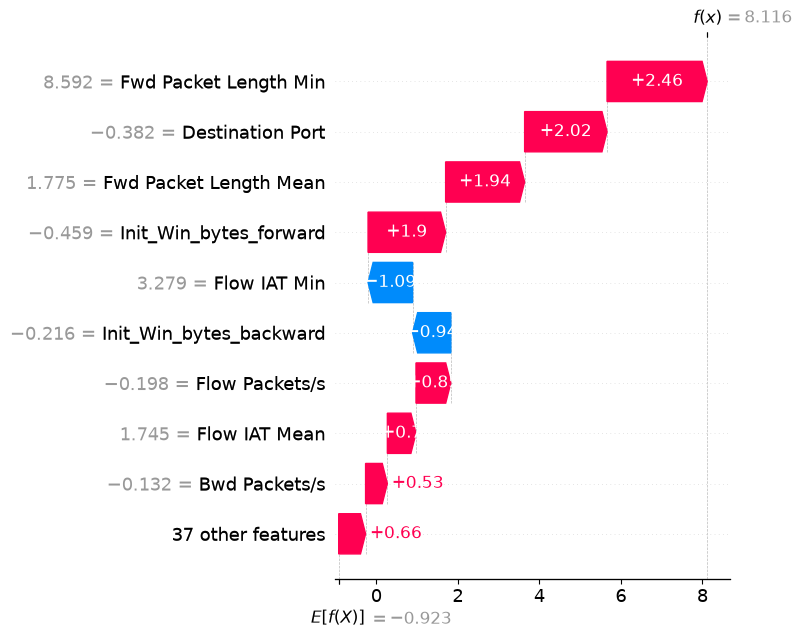

In [8]:
# Explain one individual prediction(local explainability)

attack_indices = np.where(xgb.predict(X_shap_sample_df) == 1)[0]
sample_i = attack_indices[0]

plt.figure()
shap.plots.waterfall(shap.Explanation(
    values=shap_values[sample_i],
    base_values=explainer.expected_value,
    data=X_shap_sample_df.iloc[sample_i],
    feature_names=X.columns.tolist(),
), show=False)

plt.tight_layout()
plt.savefig("../reports/shap_single_prediction.png", dpi=150, bbox_inches='tight')
plt.show()

In [10]:
np.save("../reports/shap_values_sample.npy", shap_values)
X_shap_sample_df.to_csv("../data/processed/shap_sample.data.csv", index=False)